# Byggelån for the renovation project — interest over the building period

**Project:** A/B T/R 1976, Tagensvej 58-68 / Rådmandsgade 49-53 og 49B
(BFE 480925/561569/562042).
**Source:** *Procesark – bygningsrenoveringspuljen – licitation* (application
for byfornyelse support, EKJ Rådgivende Ingeniører / PG Administration).

**Assumptions**

- The whole project is financed by a **byggelån** (construction credit), no
  mortgage loan and no savings during the building period.
- Interest rate **4.76 %** p.a., charged monthly (4.76 % / 12) on the drawn
  balance.
- The cost is paid in **24 equal monthly installments**; each installment is
  drawn on the byggelån when it is paid.
- Interest is **added to the byggelån** (capitalised) — the usual set-up for
  a byggelån. The case where the interest is paid every month instead is
  shown for comparison.
- The start month is a placeholder (January 2027); it does not change the
  total interest.

The procesark lists *Byggelånsrenter* as 0,00 kr. This notebook computes the
amount.

In [1]:
import sys
from pathlib import Path

# Use the repository's src/ when pyabf is not installed
src = Path.cwd().parent / "src" if Path.cwd().name == "ABTR1976" else Path.cwd() / "src"
if src.exists() and str(src) not in sys.path:
    sys.path.insert(0, str(src))

import matplotlib.pyplot as plt
import pandas as pd

from pyabf import ProjectFinancing, ProjectPlan

# Whole kroner, except small numbers (percentages)
pd.set_option("display.float_format",
              lambda v: f"{v:,.2f}" if abs(v) < 100 else f"{v:,.0f}")

## 1. The budget from the procesark

Section 8, *De budgetterede udgifter* (all supported works, incl. VAT):

In [2]:
budget_lines = {
    "Håndværkerudgifter": 18_858_100.00,
    "Afsatte beløb (rådgivers specifikation)": 6_283_710.00,
    "Tekniske udgifter (teknikerhonorar 15 % + bygherreudgifter)": 4_271_271.50,
    "Moms": 7_353_270.38,
}
budget = sum(budget_lines.values())

pd.Series(budget_lines | {"Samlede ombygningsudgifter": budget},
          name="DKK").to_frame()

,DKK
Håndværkerudgifter,"18,858,100"
Afsatte beløb (rådgivers specifikation),"6,283,710"
Tekniske udgifter (teknikerhonorar 15 % + bygherreudgifter),"4,271,272"
Moms,"7,353,270"
Samlede ombygningsudgifter,"36,766,352"


In [3]:
assert round(budget, 2) == 36_766_351.88  # "Samlede ombygningsudgifter jf. skema"

## 2. Project and financing

In [4]:
INTEREST_RATE = 0.0476
MONTHS = 24

plan = ProjectPlan(
    "Bygningsrenovering",
    budget=budget,
    duration_months=MONTHS,
    start_year=2027, start_month=1,   # placeholder start
)

byggelaan = ProjectFinancing(
    plan,
    credit_fraction=1.0,               # 100 % byggelån
    credit_interest_rate=INTEREST_RATE,
    capitalize_credit_interest=True,   # interest added to the byggelån
    credit_settlement="liquid",        # the take-out at the end is not modelled here
)

print(f"Monthly installment: {plan.monthly_payment:,.2f} kr.")

Monthly installment: 1,531,931.33 kr.


## 3. Month by month

Each month the interest is charged on the balance at the start of the month,
then the month's installment is drawn. So the first installment carries no
interest in month 1, and the last installment carries none at all.

In [5]:
schedule = byggelaan.schedule()
credit_at_end = byggelaan.credit_balance_at_end

monthly = schedule[["year", "month", "credit_draw", "credit_interest"]].copy()
monthly["cumulative_draws"] = monthly["credit_draw"].cumsum()
monthly["cumulative_interest"] = monthly["credit_interest"].cumsum()
monthly["byggelaan_balance"] = monthly["cumulative_draws"] + monthly["cumulative_interest"]
monthly.index = pd.RangeIndex(1, MONTHS + 1, name="month_no")
monthly

,year,month,credit_draw,credit_interest,cumulative_draws,cumulative_interest,byggelaan_balance
month_no,,,,,,,
1,2027,1,"1,531,931",0.00,"1,531,931",0.00,"1,531,931"
2,2027,2,"1,531,931","6,077","3,063,863","6,077","3,069,939"
3,2027,3,"1,531,931","12,177","4,595,794","18,254","4,614,048"
4,2027,4,"1,531,931","18,302","6,127,725","36,556","6,164,282"
5,2027,5,"1,531,931","24,452","7,659,657","61,008","7,720,665"
6,2027,6,"1,531,931","30,625","9,191,588","91,633","9,283,221"
7,2027,7,"1,531,931","36,823","10,723,519","128,457","10,851,976"
8,2027,8,"1,531,931","43,046","12,255,451","171,503","12,426,954"
9,2027,9,"1,531,931","49,294","13,787,382","220,797","14,008,179"


In [6]:
byggelaan.annual_schedule()[["credit_draw", "credit_interest"]].assign(
    byggelaan_balance_year_end=monthly.groupby("year")["byggelaan_balance"].last())

,credit_draw,credit_interest,byggelaan_balance_year_end
year,,,
2027,"18,383,176","406,410","18,789,586"
2028,"18,383,176","1,320,567","38,493,329"


## 4. Result: interest accumulated at the end of the period

In [7]:
capitalised_interest = monthly["cumulative_interest"].iloc[-1]

paid_monthly = ProjectFinancing(
    plan, credit_fraction=1.0, credit_interest_rate=INTEREST_RATE,
    capitalize_credit_interest=False, credit_settlement="liquid",
)
simple_interest = paid_monthly.summary()["credit_interest"]

result = pd.DataFrame({
    "Interest (kr.)": [capitalised_interest, simple_interest],
    "Byggelån at the end (kr.)": [credit_at_end, budget],
    "Interest in % of budget": [capitalised_interest / budget * 100,
                                simple_interest / budget * 100],
}, index=["Interest added to the byggelån (capitalised)",
          "Interest paid every month"])
result

,Interest (kr.),Byggelån at the end (kr.),Interest in % of budget
Interest added to the byggelån (capitalised),"1,726,977","38,493,329",4.70
Interest paid every month,"1,677,158","36,766,352",4.56


In [8]:
print(f"Byggelånsrenter over {MONTHS} months at {INTEREST_RATE:.2%}: "
      f"{capitalised_interest:,.0f} kr.")
print(f"Byggelån to be taken out at the end of the project: {credit_at_end:,.0f} kr.")

Byggelånsrenter over 24 months at 4.76%: 1,726,977 kr.
Byggelån to be taken out at the end of the project: 38,493,329 kr.


### Check

With the interest paid every month, the balance before month *k*'s
interest is (*k* − 1) installments, so the total interest is

$$\text{interest} = \frac{r}{12} \cdot \frac{B}{24} \cdot \sum_{k=1}^{24} (k-1)
= \frac{r}{12} \cdot B \cdot 11.5$$

Capitalising adds interest on interest, which is a little more.

In [9]:
closed_form = INTEREST_RATE / 12 * budget * (MONTHS - 1) / 2
assert abs(closed_form - simple_interest) < 0.01
print(f"Closed form: {closed_form:,.0f} kr.  Model: {simple_interest:,.0f} kr.")

Closed form: 1,677,158 kr.  Model: 1,677,158 kr.


### Timing of the draws

The model draws each installment at the end of its month. If the bank pays
out at the start of the month, every installment carries one more month of
interest; this gives an upper bound:

In [10]:
r = INTEREST_RATE / 12
installment = budget / MONTHS
balance = 0.0
for _ in range(MONTHS):
    balance = (balance + installment) * (1 + r)   # draw first, then interest
start_of_month_interest = balance - budget

pd.Series({
    "Draws at the end of the month (model)": capitalised_interest,
    "Draws at the start of the month": start_of_month_interest,
}, name="Capitalised interest (kr.)").to_frame()

,Capitalised interest (kr.)
Draws at the end of the month (model),"1,726,977"
Draws at the start of the month,"1,879,668"


## 5. Chart

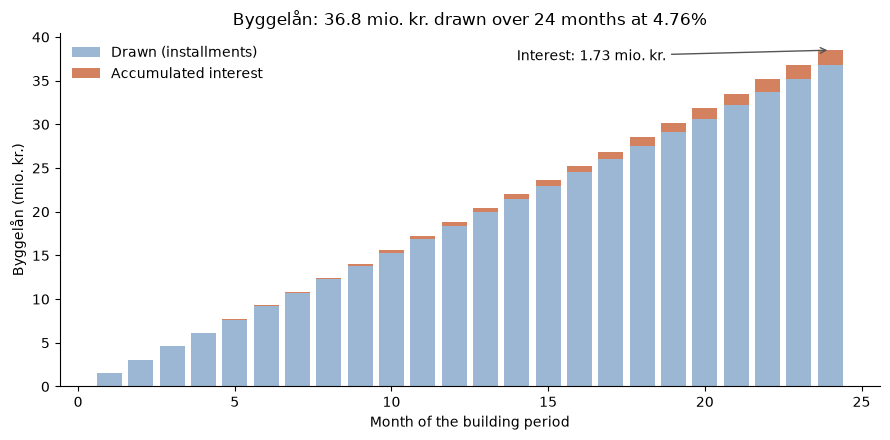

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = monthly.index
ax.bar(x, monthly["cumulative_draws"] / 1e6, color="#9bb7d4", label="Drawn (installments)")
ax.bar(x, monthly["cumulative_interest"] / 1e6, bottom=monthly["cumulative_draws"] / 1e6,
       color="#d4815f", label="Accumulated interest")
ax.set_xlabel("Month of the building period")
ax.set_ylabel("Byggelån (mio. kr.)")
ax.set_title(f"Byggelån: {budget/1e6:,.1f} mio. kr. drawn over {MONTHS} months at "
             f"{INTEREST_RATE:.2%}")
ax.annotate(f"Interest: {capitalised_interest/1e6:,.2f} mio. kr.",
            xy=(MONTHS, credit_at_end / 1e6), xytext=(MONTHS - 10, credit_at_end / 1e6 * 0.97),
            arrowprops=dict(arrowstyle="->", color="#555"))
ax.legend(frameon=False, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Notes

- **Not modelled:** byggelån fees (stiftelsesprovision, tinglysning) and any
  interest on the part of the project covered by support. Add them to
  *Låneomkostninger* in the procesark if relevant.
- **Circularity:** if the byggelånsrenter are themselves financed by the
  byggelån and included in the eligible costs, the budget grows by the
  interest and the interest grows slightly with it.
- **After the building period** the byggelån is normally replaced by a
  mortgage loan (or paid from savings). Set `credit_settlement="loan"` and
  pass `loan=Loan(...)` to `ProjectFinancing` to model the take-out loan.